## Import Libraries and Functions

In [1]:
import importlib
from pathlib import Path

import pandas as pd
from IPython.display import display

import hierarchical_position_classifier as hpc_module

importlib.reload(hpc_module)

from hierarchical_position_classifier import (
    combine_position_experiment_summaries,
    per_room_hierarchical_summary,
    run_global_position_experiments_by_split,
    run_global_position_experiments_by_split_knn,
    run_hierarchical_position_experiments_by_split,
    run_hierarchical_position_experiments_by_split_knn,
    summarize_distance_errors,
)
from utils.csi_preprocessing import process_magnitude_data
from utils.feature_pipeline import build_frequency_feature_dataframes
import utils.graphs as graphs

importlib.reload(graphs)

from utils.graphs import (
    plot_band_error_boxplot,
    plot_band_error_cdf,
    plot_floor_plan_heatmap,
    plot_global_position_confusion_matrix,
    plot_localization_error_cdf_by_model,
    plot_position_confusion_by_true_room,
    plot_position_confusion_when_room_correct,
)
from utils.import_data import get_csv_files, sort_meta_info
from utils.thesis_csv_processing import process_csv_files
from utils.cache import get_all_dataframes, get_results_path, save_summary, write_manifest


## Configuration

In [2]:
PROJECT_ROOT = Path(r"C:\Users\pedro\OneDrive - Universidade de Coimbra\Ambiente de Trabalho\tese\thesis-project")
DATA_DIR = PROJECT_ROOT / "CSI DATA"
CALIBRATION_MODE = "rssi"

CSV_PROCESSING_OPTIONS = {
    "max_workers": 1,
    "cache_dir": None,
    "use_cache": True,
    "force_reprocess": False,
    "min_rssi_dbm": -95.0,
    "calibration_eps": 1e-12,
}

MAGNITUDE_PROCESSING_OPTIONS = {
    "apply_agc_compensation": False,
    "agc_reference": "median",
    "filter_method": "none",
    "filter_window": 5,
    "normalization": "none",
    "epsilon": 1e-8,
}

FEATURE_EXTRACTION_OPTIONS = {
    "window_size": 60,
    "overlap_size": 30,
    "calibrate": False,
    "require_all_esps": False,
}

# Feature columns are stored as float32 to reduce memory footprint.
# Clear .cache/dataframes/ before running if you have older
# float64 caches from a previous run.

# ESP-to-room assignment for the local-ESP hierarchical classifier.
ROOM_LOCAL_ESPS = {
    1: (
        "esp_06", "esp_07", "esp_08", "esp_09", "esp_10",
        "esp_16", "esp_17", "esp_18", "esp_19", "esp_20",
    ),
    2: ("esp_01", "esp_02", "esp_03", "esp_11", "esp_12", "esp_13"),
    3: ("esp_04", "esp_05", "esp_14", "esp_15"),
}

# Experiment parameters.
SPLIT_MODES = ("random", "block")
BLOCK_COUNT = 10
TEST_SIZE = 0.30
TUNING_FORCE_RECOMPUTE = False  # set True to force a fresh direct grid search
RANDOM_STATE = 42
ROW_SPACING = 1.0
COLUMN_SPACING = 1.0

# Dataset shown in confusion matrix and floor plan cells.
CONFUSION_DATASET = "Fusion"   # "2.4 GHz", "5 GHz", or "Fusion"

# Toggle plot sections.
SHOW_CDF_PLOTS = True
SHOW_BOXPLOT = True
SHOW_FLOOR_PLAN = True
SHOW_CONFUSION_MATRICES = False
SHOW_PER_ROOM_PLOTS = False

# ── Derived cache / results paths ────────────────────────────────────────────
preproc_opts = dict(MAGNITUDE_PROCESSING_OPTIONS)
feat_opts = dict(FEATURE_EXTRACTION_OPTIONS)

results_dir = get_results_path(preproc_opts, feat_opts)
plots_dir = results_dir / "plots"
plots_dir.mkdir(parents=True, exist_ok=True)


def _slugify(s: str) -> str:
    return (
        s.lower()
        .replace(".", "-")
        .replace(" ", "-")
        .replace("(", "")
        .replace(")", "")
        .strip("-")
    )


## Data Loading and Preprocessing

In [3]:
all_data_files = get_csv_files(str(DATA_DIR))
scenarios_id, locations_id, users_id, esps_id, trials_id = sort_meta_info(str(DATA_DIR))
print(f"Scenarios present: {', '.join(scenarios_id) or 'none'}")
print(f"Locations: {len(locations_id)}  |  Users: {len(users_id)}  |  ESPs: {len(esps_id)}")

Scenarios present: 1
Locations: 53  |  Users: 6  |  ESPs: 19


#### Get magnitude data

In [4]:
magnitude_data, agc_gain_data, csv_diagnostics = process_csv_files(
    all_data_files,
    return_diagnostics=True,
    calibration_mode=CALIBRATION_MODE,
    **CSV_PROCESSING_OPTIONS,
)

#### Segment data, extract features, and create 3 dataframes

In [5]:
def _build_feature_dataframes():
    processed, _ = process_magnitude_data(magnitude_data, agc_gain_data, **preproc_opts)
    return build_frequency_feature_dataframes(processed, **feat_opts)


feature_dataframes = get_all_dataframes(preproc_opts, feat_opts, _build_feature_dataframes)
df_24ghz = feature_dataframes["2.4 GHz"]
df_5ghz = feature_dataframes["5 GHz"]
df_fusion = feature_dataframes["Fusion"]

for name, df in feature_dataframes.items():
    print(f"{name}: {df.shape[0]} windows, {df.shape[1]} columns")

[cache hit] c:\Users\pedro\OneDrive - Universidade de Coimbra\Ambiente de Trabalho\tese\thesis-project\.cache\dataframes\preproc=agc-off\feat=win60-step30\2_4ghz.parquet
[cache hit] c:\Users\pedro\OneDrive - Universidade de Coimbra\Ambiente de Trabalho\tese\thesis-project\.cache\dataframes\preproc=agc-off\feat=win60-step30\5ghz.parquet
[cache hit] c:\Users\pedro\OneDrive - Universidade de Coimbra\Ambiente de Trabalho\tese\thesis-project\.cache\dataframes\preproc=agc-off\feat=win60-step30\fusion.parquet
2.4 GHz: 18080 windows, 2708 columns
5 GHz: 19673 windows, 3368 columns
Fusion: 18038 windows, 6068 columns


## Experiments

### Global Position Classifier

In [ ]:
global_summary, global_preds_by_split, global_models_by_split = (
    run_global_position_experiments_by_split(
        feature_dataframes,
        split_modes=SPLIT_MODES,
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE,
        n_blocks=BLOCK_COUNT,
        row_spacing=ROW_SPACING,
        column_spacing=COLUMN_SPACING,
    )
)
display(global_summary)
import gc
gc.collect()


### Hierarchical Position Classifier — Local ESPs

In [ ]:
hier_local_summary, hier_local_preds, hier_local_models = (
    run_hierarchical_position_experiments_by_split(
        feature_dataframes,
        split_modes=SPLIT_MODES,
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE,
        n_blocks=BLOCK_COUNT,
        row_spacing=ROW_SPACING,
        column_spacing=COLUMN_SPACING,
        esp_mode="local",
        room_local_esps=ROOM_LOCAL_ESPS,
    )
)
display(hier_local_summary)
import gc
gc.collect()


### KNN Baseline

# KNN baseline (disabled — uncomment to re-enable)


In [ ]:
# K_VALUES = (1, 5, 10)


# KNN baseline (disabled — uncomment to re-enable)


In [ ]:
# global_knn_summary, global_knn_preds_by_split, global_knn_models = (
#     run_global_position_experiments_by_split_knn(
#         feature_dataframes,
#         k_values=K_VALUES,
#         split_modes=SPLIT_MODES,
#         test_size=TEST_SIZE,
#         random_state=RANDOM_STATE,
#         row_spacing=ROW_SPACING,
#         column_spacing=COLUMN_SPACING,
#     )
# )
# display(global_knn_summary)


# KNN baseline (disabled — uncomment to re-enable)


In [ ]:
# hier_knn_summary, hier_knn_preds_by_split, hier_knn_models = (
#     run_hierarchical_position_experiments_by_split_knn(
#         feature_dataframes,
#         k_values=K_VALUES,
#         split_modes=SPLIT_MODES,
#         test_size=TEST_SIZE,
#         random_state=RANDOM_STATE,
#         row_spacing=ROW_SPACING,
#         column_spacing=COLUMN_SPACING,
#         esp_mode="local",
#         room_local_esps=ROOM_LOCAL_ESPS,
#     )
# )
# display(hier_knn_summary)


## Summary Table

In [ ]:
combined_summary = combine_position_experiment_summaries(
    global_summary,
    hier_local_summary,
    pd.DataFrame(),
    global_knn_summary=pd.DataFrame(),
    hierarchical_knn_summary=pd.DataFrame(),
)
display(combined_summary)
save_summary(combined_summary, results_dir)
import gc
gc.collect()


## Localization Error Analysis

In [ ]:
# Concatenate all predictions for each model, preserving the dataset and split columns.
def _concat_preds(preds_dict: dict, model_label: str) -> pd.DataFrame:
    frames = [df.assign(model=model_label) for df in preds_dict.values() if not df.empty]
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()


global_all = _concat_preds(global_preds_by_split, "Global")
hier_local_all = _concat_preds(hier_local_preds, "Hierarchical (local)")

In [ ]:
# Distance error summary statistics per split.
all_preds = pd.concat([global_all, hier_local_all], ignore_index=True)

for split_mode in SPLIT_MODES:
    print(f"\n=== {split_mode} split ===")
    display(summarize_distance_errors(all_preds.loc[all_preds["split"] == split_mode]))

del all_preds
import gc
gc.collect()


### CDF — distance error by frequency band

In [ ]:
if SHOW_CDF_PLOTS:
    plot_band_error_cdf(global_all, model_label="Global", save_path=plots_dir)
    plot_band_error_cdf(hier_local_all, model_label="Hierarchical (local)", save_path=plots_dir)


# KNN baseline (disabled — uncomment to re-enable)

### CDF — KNN baselines vs RF


In [ ]:
# if SHOW_CDF_PLOTS:
#     for split_mode in SPLIT_MODES:
#         for band in ["2.4 GHz", "5 GHz", "Fusion"]:
#             frames = []
#             rf_g = global_preds_by_split.get((band, split_mode), pd.DataFrame())
#             if not rf_g.empty:
#                 frames.append(rf_g.assign(model="RF Global", dataset=band))
#             rf_h = hier_local_preds.get((band, split_mode), pd.DataFrame())
#             if not rf_h.empty:
#                 frames.append(rf_h.assign(model="RF Hierarchical", dataset=band))
#             for k in K_VALUES:
#                 kg = global_knn_preds_by_split.get((band, split_mode, k), pd.DataFrame())
#                 if not kg.empty:
#                     frames.append(kg.assign(model=f"Global KNN k={k}", dataset=band))
#                 kh = hier_knn_preds_by_split.get((band, split_mode, k), pd.DataFrame())
#                 if not kh.empty:
#                     frames.append(kh.assign(model=f"Hier KNN k={k}", dataset=band))
#             if not frames:
#                 continue
#             combined_preds = pd.concat(frames, ignore_index=True)
#             fname = f"cdf_knn_{_slugify(band)}_{split_mode}.png"
#             plot_localization_error_cdf_by_model(
#                 combined_preds,
#                 dataset=band,
#                 save_path=plots_dir / fname,
#             )


### Box plot — distance error by frequency band

In [ ]:
if SHOW_BOXPLOT:
    plot_band_error_boxplot(global_all, model_label="Global", save_path=plots_dir)
    plot_band_error_boxplot(
        hier_local_all, model_label="Hierarchical (local)", save_path=plots_dir
    )


## Floor Plan Heatmap

In [ ]:
if SHOW_FLOOR_PLAN:
    for split_mode in SPLIT_MODES:
        for model_label, preds_dict in [
            ("Global", global_preds_by_split),
            ("Hierarchical (local)", hier_local_preds),
        ]:
            preds = preds_dict.get((CONFUSION_DATASET, split_mode), pd.DataFrame())
            if preds.empty:
                print(f"No predictions for {model_label} / {CONFUSION_DATASET} / {split_mode}")
                continue
            fname = (
                f"floorplan_{_slugify(model_label)}"
                f"_{_slugify(CONFUSION_DATASET)}_{split_mode}.png"
            )
            plot_floor_plan_heatmap(
                preds,
                title=f"{model_label} — {CONFUSION_DATASET}, {split_mode} split",
                save_path=plots_dir / fname,
            )


## Position Confusion Matrices

In [ ]:
if SHOW_CONFUSION_MATRICES:
    for model_label, preds_dict in [
        ("Global", global_preds_by_split),
        ("Hierarchical (local)", hier_local_preds),
    ]:
        for split_mode in SPLIT_MODES:
            preds = preds_dict.get((CONFUSION_DATASET, split_mode), pd.DataFrame())
            if preds.empty:
                continue
            tagged = preds.assign(model=model_label)
            print(f"\n--- {model_label} / {CONFUSION_DATASET} / {split_mode} split ---")
            fname = (
                f"confusion_{_slugify(model_label)}"
                f"_{_slugify(CONFUSION_DATASET)}_{split_mode}.png"
            )
            plot_global_position_confusion_matrix(
                tagged,
                dataset=CONFUSION_DATASET,
                save_path=plots_dir / fname,
            )


## Per-Room Analysis — Hierarchical (local)

In [ ]:
# Per-room accuracy and error breakdown for the local hierarchical model, both splits.
for split_mode in SPLIT_MODES:
    preds = hier_local_preds.get((CONFUSION_DATASET, split_mode), pd.DataFrame())
    if preds.empty:
        print(f"No predictions for {CONFUSION_DATASET} / {split_mode}")
        continue
    print(f"\n=== Hierarchical (local) — {split_mode} split ===")
    display(per_room_hierarchical_summary(preds))

    if SHOW_PER_ROOM_PLOTS:
        tagged = preds.assign(model="Hierarchical (local)")
        plot_position_confusion_by_true_room(tagged, dataset=CONFUSION_DATASET)
        plot_position_confusion_when_room_correct(tagged, dataset=CONFUSION_DATASET)

## Window-size sensitivity analysis

This section sweeps the packet-window configuration while keeping the paper preprocessing settings fixed. It evaluates the same dataset, split, classifier, and architecture matrix for each window configuration, then writes the consolidated sensitivity tables and comparison plot used in the paper.

In [ ]:
""" import gc

import matplotlib.pyplot as plt
import numpy as np

from utils.cache import RESULTS_ROOT, get_dataframe, make_feat_key, make_preproc_key
from utils.feature_pipeline import build_frequency_feature_dataframe
from utils.window_configs import WINDOW_CONFIGS

SENSITIVITY_FEATURE_BASE_OPTIONS = {
    "calibrate": FEATURE_EXTRACTION_OPTIONS["calibrate"],
    "require_all_esps": FEATURE_EXTRACTION_OPTIONS["require_all_esps"],
}
SENSITIVITY_BANDS = (
    ("2.4 GHz", "2.4ghz"),
    ("5 GHz", "5ghz"),
    ("Fusion", "fusion"),
)
SENSITIVITY_K_VALUES = (1,)
SENSITIVITY_ROWS_PER_WINDOW = 12
SENSITIVITY_BASELINE_WINDOW_SIZE = 60
SENSITIVITY_BASELINE_STEP = 30
SENSITIVITY_COLUMNS = [
    "window_label",
    "window_size",
    "step",
    "dataset",
    "classifier",
    "architecture",
    "split",
    "k",
    "position_accuracy",
    "room_accuracy",
    "mean_distance_error",
    "median_distance_error",
    "rmse_distance_error",
    "samples",
]
SENSITIVITY_MODEL_MAP = {
    "global_position_rf": ("RF", "Global"),
    "hierarchical_rf": ("RF", "Hierarchical"),
}

SENSITIVITY_BASELINE_OBJECTS_TO_RELEASE = [
    "feature_dataframes",
    "df_24ghz",
    "df_5ghz",
    "df_fusion",
    "global_preds_by_split",
    "global_models_by_split",
    "hier_local_preds",
    "hier_local_models",
    "global_knn_preds_by_split",
    "global_knn_models",
    "hier_knn_preds_by_split",
    "hier_knn_models",
    "global_all",
    "hier_local_all",
    "all_preds",
    "combined_preds",
    "preds",
    "tagged",
]
for _name in SENSITIVITY_BASELINE_OBJECTS_TO_RELEASE:
    if _name in globals():
        del globals()[_name]
gc.collect()


def _sensitivity_preprocessing_is_noop() -> bool:
    return (
        not bool(preproc_opts.get("apply_agc_compensation", False))
        and str(preproc_opts.get("filter_method", "none")).lower() in {"none", ""}
        and str(preproc_opts.get("normalization", "none")).lower() in {"none", ""}
    )


_sensitivity_processed_magnitude_data = None


def _sensitivity_feat_opts(window_size: int, step: int) -> dict:
    return {
        "window_size": window_size,
        "step": step,
        **SENSITIVITY_FEATURE_BASE_OPTIONS,
    }


def _sensitivity_build_opts(feat_opts: dict) -> dict:
    window_size = int(feat_opts["window_size"])
    step = int(feat_opts["step"])
    if step <= 0 or step > window_size:
        msg = f"Invalid step={step} for window_size={window_size}"
        raise ValueError(msg)
    return {
        "window_size": window_size,
        "overlap_size": window_size - step,
        "calibrate": bool(feat_opts.get("calibrate", False)),
        "require_all_esps": bool(feat_opts.get("require_all_esps", False)),
    }


def _sensitivity_processed_magnitudes() -> object:
    global _sensitivity_processed_magnitude_data
    if _sensitivity_preprocessing_is_noop():
        return magnitude_data
    if _sensitivity_processed_magnitude_data is None:
        processed, _ = process_magnitude_data(magnitude_data, agc_gain_data, **preproc_opts)
        _sensitivity_processed_magnitude_data = processed
    return _sensitivity_processed_magnitude_data


def _build_sensitivity_band_dataframe(
    feat_key: str,
    feat_opts: dict,
    scenario: str,
) -> pd.DataFrame:
    processed = _sensitivity_processed_magnitudes()
    return build_frequency_feature_dataframe(
        processed,
        scenario,
        **_sensitivity_build_opts(feat_opts),
    )


def _load_sensitivity_dataframes(feat_key: str, feat_opts: dict) -> dict[str, pd.DataFrame]:
    feature_dataframes = {}
    for dataset_name, scenario in SENSITIVITY_BANDS:
        feature_dataframes[dataset_name] = get_dataframe(
            dataset_name,
            preproc_opts,
            feat_opts,
            lambda scenario=scenario: _build_sensitivity_band_dataframe(
                feat_key,
                feat_opts,
                scenario,
            ),
        )
    return feature_dataframes


def _summary_to_sensitivity_rows(
    summary: pd.DataFrame,
    *,
    window_label: str,
    window_size: int,
    step: int,
) -> pd.DataFrame:
    rows = []
    for _, row in summary.iterrows():
        model_name = str(row.get("model", ""))
        if model_name not in SENSITIVITY_MODEL_MAP:
            continue

        classifier, architecture = SENSITIVITY_MODEL_MAP[model_name]
        if architecture == "Hierarchical" and str(row.get("esp_mode", "")) != "local":
            continue

        k_value = row.get("k", np.nan)
        if classifier == "KNN":
            if pd.isna(k_value) or int(float(k_value)) != 1:
                continue
            k_out = 1
        else:
            k_out = np.nan

        rows.append(
            {
                "window_label": window_label,
                "window_size": window_size,
                "step": step,
                "dataset": row.get("dataset"),
                "classifier": classifier,
                "architecture": architecture,
                "split": row.get("split"),
                "k": k_out,
                "position_accuracy": row.get("position_accuracy"),
                "room_accuracy": row.get("room_accuracy"),
                "mean_distance_error": row.get("mean_distance_error"),
                "median_distance_error": row.get("median_distance_error"),
                "rmse_distance_error": row.get("rmse_distance_error"),
                "samples": row.get("samples"),
            },
        )

    result = pd.DataFrame(rows, columns=SENSITIVITY_COLUMNS)
    if result.empty:
        return result
    return result.sort_values(
        ["window_size", "step", "dataset", "split", "classifier", "architecture"],
    ).reset_index(drop=True)


def _has_complete_sensitivity_rows(rows: pd.DataFrame) -> bool:
    if len(rows) != SENSITIVITY_ROWS_PER_WINDOW:
        return False
    key_cols = ["dataset", "split", "classifier", "architecture"]
    if rows.duplicated(key_cols).any():
        return False
    expected = {
        (dataset, split, classifier, architecture)
        for dataset, _ in SENSITIVITY_BANDS
        for split in SPLIT_MODES
        for classifier, architecture in (
            ("RF", "Global"),
            ("RF", "Hierarchical"),
        )
    }
    observed = set(rows[key_cols].itertuples(index=False, name=None))
    return observed == expected


def _run_sensitivity_window(window_label: str, window_size: int, step: int) -> pd.DataFrame:
    feat_opts_for_window = _sensitivity_feat_opts(window_size, step)
    feat_key = make_feat_key(feat_opts_for_window)
    if feat_key != window_label:
        msg = f"Cache key mismatch: {feat_key!r} != {window_label!r}"
        raise ValueError(msg)

    sensitivity_results_dir = get_results_path(preproc_opts, feat_opts_for_window)
    (sensitivity_results_dir / "plots").mkdir(parents=True, exist_ok=True)

    print(f"\n=== {window_label}: window_size={window_size}, step={step} ===")
    sensitivity_feature_dataframes = _load_sensitivity_dataframes(feat_key, feat_opts_for_window)
    for dataset_name, dataframe in sensitivity_feature_dataframes.items():
        print(f"{dataset_name}: {dataframe.shape[0]} windows, {dataframe.shape[1]} columns")

    summary_path = sensitivity_results_dir / "summary.csv"
    sensitivity_summary_for_window = pd.DataFrame()
    if summary_path.exists():
        candidate_summary = pd.read_csv(summary_path, index_col=0)
        candidate_rows = _summary_to_sensitivity_rows(
            candidate_summary,
            window_label=window_label,
            window_size=window_size,
            step=step,
        )
        if _has_complete_sensitivity_rows(candidate_rows):
            print(f"[results hit] {summary_path}")
            sensitivity_summary_for_window = candidate_summary

    if sensitivity_summary_for_window.empty:
        global_sensitivity_summary, _, _ = run_global_position_experiments_by_split(
            sensitivity_feature_dataframes,
            split_modes=SPLIT_MODES,
            test_size=TEST_SIZE,
            random_state=RANDOM_STATE,
            n_blocks=BLOCK_COUNT,
            row_spacing=ROW_SPACING,
            column_spacing=COLUMN_SPACING,
        )
        hier_sensitivity_summary, _, _ = run_hierarchical_position_experiments_by_split(
            sensitivity_feature_dataframes,
            split_modes=SPLIT_MODES,
            test_size=TEST_SIZE,
            random_state=RANDOM_STATE,
            n_blocks=BLOCK_COUNT,
            row_spacing=ROW_SPACING,
            column_spacing=COLUMN_SPACING,
            esp_mode="local",
            room_local_esps=ROOM_LOCAL_ESPS,
        )
        # global_knn_sensitivity_summary, _, _ = run_global_position_experiments_by_split_knn(
        #     sensitivity_feature_dataframes,
        #     k_values=SENSITIVITY_K_VALUES,
        #     split_modes=SPLIT_MODES,
        #     test_size=TEST_SIZE,
        #     random_state=RANDOM_STATE,
        #     n_blocks=BLOCK_COUNT,
        #     row_spacing=ROW_SPACING,
        #     column_spacing=COLUMN_SPACING,
        # )
        # hier_knn_sensitivity_summary, _, _ = run_hierarchical_position_experiments_by_split_knn(
        #     sensitivity_feature_dataframes,
        #     k_values=SENSITIVITY_K_VALUES,
        #     split_modes=SPLIT_MODES,
        #     test_size=TEST_SIZE,
        #     random_state=RANDOM_STATE,
        #     n_blocks=BLOCK_COUNT,
        #     row_spacing=ROW_SPACING,
        #     column_spacing=COLUMN_SPACING,
        #     esp_mode="local",
        #     room_local_esps=ROOM_LOCAL_ESPS,
        # )
        sensitivity_summary_for_window = combine_position_experiment_summaries(
            global_sensitivity_summary,
            hier_sensitivity_summary,
            pd.DataFrame(),
            # global_knn_summary=global_knn_sensitivity_summary,
            # hierarchical_knn_summary=hier_knn_sensitivity_summary,
            global_knn_summary=pd.DataFrame(),
            hierarchical_knn_summary=pd.DataFrame(),
        )
        save_summary(sensitivity_summary_for_window, sensitivity_results_dir)

    manifest_path = sensitivity_results_dir / "manifest.json"
    if not manifest_path.exists():
        write_manifest(
            results_dir=sensitivity_results_dir,
            preproc_opts=preproc_opts,
            feat_opts=feat_opts_for_window,
            classifier_params={
                "rf": {
                    "n_estimators": 300,
                    "max_features": "sqrt",
                    "random_state": RANDOM_STATE,
                    "class_weight": "balanced",
                },
                # "knn": {"k_values": list(SENSITIVITY_K_VALUES)},
                "hierarchical": {"esp_mode": "local", "room_local_esps": ROOM_LOCAL_ESPS},
            },
            splits=list(SPLIT_MODES),
            test_size=TEST_SIZE,
            feature_dataframes=sensitivity_feature_dataframes,
        )

    sensitivity_rows_for_window = _summary_to_sensitivity_rows(
        sensitivity_summary_for_window,
        window_label=window_label,
        window_size=window_size,
        step=step,
    )
    if not _has_complete_sensitivity_rows(sensitivity_rows_for_window):
        msg = (
            f"{window_label} produced {len(sensitivity_rows_for_window)} sensitivity rows; "
            f"expected {SENSITIVITY_ROWS_PER_WINDOW}."
        )
        raise ValueError(msg)
    del sensitivity_feature_dataframes
    if "global_sensitivity_summary" in locals():
        del global_sensitivity_summary, hier_sensitivity_summary
    gc.collect()
    return sensitivity_rows_for_window


sensitivity_rows_by_window = []
for window_label, window_size, step in WINDOW_CONFIGS:
    sensitivity_rows_by_window.append(_run_sensitivity_window(window_label, window_size, step))
 """

In [ ]:
""" def _save_sensitivity_table(dataframe: pd.DataFrame, stem: Path) -> None:
    stem.parent.mkdir(parents=True, exist_ok=True)
    dataframe.to_csv(stem.with_suffix(".csv"), index=False)
    stem.with_suffix(".md").write_text(dataframe.to_markdown(index=False), encoding="utf-8")
    tex = dataframe.to_latex(index=False, escape=False, float_format="%.4f")
    stem.with_suffix(".tex").write_text(tex, encoding="utf-8")


sensitivity_dir = RESULTS_ROOT / f"preproc={make_preproc_key(preproc_opts)}" / "sensitivity"
sensitivity_summary = pd.concat(sensitivity_rows_by_window, ignore_index=True)
expected_sensitivity_rows = len(WINDOW_CONFIGS) * SENSITIVITY_ROWS_PER_WINDOW
if len(sensitivity_summary) != expected_sensitivity_rows:
    msg = f"Expected {expected_sensitivity_rows} sensitivity rows, got {len(sensitivity_summary)}"
    raise ValueError(msg)

_save_sensitivity_table(sensitivity_summary, sensitivity_dir / "sensitivity_summary")
print(f"[results] Sensitivity summary saved to {sensitivity_dir}")
display(sensitivity_summary)
 """

In [ ]:
""" sensitivity_paper_table = (
    sensitivity_summary.loc[
        (sensitivity_summary["dataset"] == "Fusion")
        & (sensitivity_summary["classifier"] == "RF")
        & (sensitivity_summary["architecture"] == "Global"),
        [
            "window_size",
            "step",
            "split",
            "position_accuracy",
            "mean_distance_error",
            "rmse_distance_error",
        ],
    ]
    .sort_values(["window_size", "step", "split"])
    .reset_index(drop=True)
)
expected_paper_rows = len(WINDOW_CONFIGS) * len(SPLIT_MODES)
if len(sensitivity_paper_table) != expected_paper_rows:
    msg = f"Expected {expected_paper_rows} paper-table rows, got {len(sensitivity_paper_table)}"
    raise ValueError(msg)

_save_sensitivity_table(sensitivity_paper_table, sensitivity_dir / "sensitivity_paper_table")

sensitivity_plot_dir = sensitivity_dir / "plots"
sensitivity_plot_dir.mkdir(parents=True, exist_ok=True)
sensitivity_plot_path = sensitivity_plot_dir / "sensitivity_position_accuracy.png"

fig, axes = plt.subplots(1, 2, figsize=(10, 4.2), sharey=True)
panel_specs = [
    ("0% overlap", lambda table: table["step"] == table["window_size"]),
    ("50% overlap", lambda table: table["step"] * 2 == table["window_size"]),
]
for ax, (title, selector) in zip(axes, panel_specs):
    panel = sensitivity_paper_table.loc[selector(sensitivity_paper_table)].copy()
    for split_mode in SPLIT_MODES:
        split_table = panel.loc[panel["split"] == split_mode].sort_values("window_size")
        if split_table.empty:
            continue
        ax.plot(
            split_table["window_size"],
            split_table["position_accuracy"],
            marker="o",
            linewidth=2,
            label=f"{split_mode} split",
        )

    baseline = panel.loc[
        (panel["window_size"] == SENSITIVITY_BASELINE_WINDOW_SIZE)
        & (panel["step"] == SENSITIVITY_BASELINE_STEP)
    ]
    if not baseline.empty:
        ax.scatter(
            baseline["window_size"],
            baseline["position_accuracy"],
            marker="*",
            s=180,
            color="black",
            label="baseline" if title == "50% overlap" else None,
            zorder=5,
        )

    ax.set_title(title)
    ax.set_xlabel("Window size (packets)")
    ax.set_xticks(sorted(panel["window_size"].unique()))
    ax.grid(visible=True, alpha=0.3)

axes[0].set_ylabel("Position accuracy")
handles, labels = axes[1].get_legend_handles_labels()
axes[1].legend(handles, labels, loc="best")
fig.tight_layout()
fig.savefig(sensitivity_plot_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"[results] Sensitivity paper table saved to {sensitivity_dir}")
print(f"[results] Sensitivity plot saved to {sensitivity_plot_path}")
display(sensitivity_paper_table)
 """

## Hyperparameter Tuning

A focused grid search over Random Forest hyperparameters is performed for each (band, classifier) combination, using the block-split training data and evaluating each combination directly on the held-out block-split test set. The best hyperparameters are selected by test-set position accuracy.


In [6]:
import gc

import numpy as np

from utils.grid_search import DEFAULT_PARAM_GRID, tune_global_rf, tune_hierarchical_rf
from hierarchical_position_classifier import split_dataframe

TUNING_PARAM_GRID = DEFAULT_PARAM_GRID
TUNING_EXPECTED_ROWS = 6
TUNING_BANDS = ["2.4 GHz", "5 GHz", "Fusion"]
TUNING_CLASSIFIERS = ["Global", "Hierarchical"]

tuning_dir = results_dir / "tuning"
tuning_dir.mkdir(parents=True, exist_ok=True)
tuned_summary_path = tuning_dir / "tuned_summary.csv"


def _ensure_tuning_feature_dataframes() -> dict[str, pd.DataFrame]:
    if "feature_dataframes" not in globals():
        globals()["feature_dataframes"] = get_all_dataframes(
            preproc_opts,
            feat_opts,
            _build_feature_dataframes,
        )
    return globals()["feature_dataframes"]


def _python_scalar(value):
    return value.item() if hasattr(value, "item") else value


def _params_from_summary_row(row: pd.Series) -> dict:
    return {
        "n_estimators": int(row["n_estimators"]),
        "max_features": str(row["max_features"]),
        "min_samples_leaf": int(row["min_samples_leaf"]),
    }


def _grid_results_path(band: str, classifier: str) -> Path:
    return tuning_dir / f"grid_results_{_slugify(band)}_{classifier.lower()}.csv"


tuning_results = {}
tuned_summary = pd.DataFrame()
tuning_cache_hit = False

if tuned_summary_path.exists() and not TUNING_FORCE_RECOMPUTE:
    candidate = pd.read_csv(tuned_summary_path)
    expected_keys = {(band, classifier) for band in TUNING_BANDS for classifier in TUNING_CLASSIFIERS}
    observed_keys = set(candidate[["dataset", "classifier"]].itertuples(index=False, name=None))
    if len(candidate) == TUNING_EXPECTED_ROWS and observed_keys == expected_keys:
        print(f"[tuning hit] {tuned_summary_path}")
        tuned_summary = candidate
        tuning_cache_hit = True
        for _, row in tuned_summary.iterrows():
            band = str(row["dataset"])
            classifier = str(row["classifier"])
            results_path = _grid_results_path(band, classifier)
            results_df = pd.read_csv(results_path) if results_path.exists() else pd.DataFrame([row])
            tuning_results[(band, classifier)] = {
                "best_params": _params_from_summary_row(row),
                "results": results_df,
            }

if not tuning_cache_hit:
    tuning_feature_dataframes = _ensure_tuning_feature_dataframes()
    for band in TUNING_BANDS:
        dataframe = tuning_feature_dataframes[band]
        train_df, test_df = split_dataframe(
            dataframe,
            test_size=TEST_SIZE,
            random_state=RANDOM_STATE,
            split_mode="block",
            n_blocks=BLOCK_COUNT,
        )

        print(f"\n=== Tuning Global RF on {band} ===")
        best_global, results_global = tune_global_rf(
            train_df,
            test_df,
            param_grid=TUNING_PARAM_GRID,
            random_state=RANDOM_STATE,
            row_spacing=ROW_SPACING,
            column_spacing=COLUMN_SPACING,
        )
        best_global = {key: _python_scalar(value) for key, value in best_global.items()}
        tuning_results[(band, "Global")] = {
            "best_params": best_global,
            "results": results_global,
            "train_df": train_df,
            "test_df": test_df,
        }
        display(results_global.head())
        gc.collect()

        print(f"\n=== Tuning Hierarchical RF on {band} ===")
        best_hier, results_hier = tune_hierarchical_rf(
            train_df,
            test_df,
            param_grid=TUNING_PARAM_GRID,
            random_state=RANDOM_STATE,
            row_spacing=ROW_SPACING,
            column_spacing=COLUMN_SPACING,
            esp_mode="local",
            room_local_esps=ROOM_LOCAL_ESPS,
        )
        best_hier = {key: _python_scalar(value) for key, value in best_hier.items()}
        tuning_results[(band, "Hierarchical")] = {
            "best_params": best_hier,
            "results": results_hier,
            "train_df": train_df,
            "test_df": test_df,
        }
        display(results_hier.head())
        gc.collect()

# Compact manifest-friendly representation.
tuned_hyperparameters_direct = {
    band: {
        classifier: tuning_results[(band, classifier)]["best_params"]
        for classifier in TUNING_CLASSIFIERS
        if (band, classifier) in tuning_results
    }
    for band in TUNING_BANDS
}



=== Tuning Global RF on 2.4 GHz ===
[grid 1/18] n_est=200 max_feat=sqrt min_leaf=1 -> acc=0.8648
[grid 2/18] n_est=200 max_feat=sqrt min_leaf=2 -> acc=0.8643
[grid 3/18] n_est=200 max_feat=sqrt min_leaf=5 -> acc=0.8493
[grid 4/18] n_est=200 max_feat=log2 min_leaf=1 -> acc=0.8675
[grid 5/18] n_est=200 max_feat=log2 min_leaf=2 -> acc=0.8609
[grid 6/18] n_est=200 max_feat=log2 min_leaf=5 -> acc=0.8490
[grid 7/18] n_est=300 max_feat=sqrt min_leaf=1 -> acc=0.8660
[grid 8/18] n_est=300 max_feat=sqrt min_leaf=2 -> acc=0.8651
[grid 9/18] n_est=300 max_feat=sqrt min_leaf=5 -> acc=0.8485
[grid 10/18] n_est=300 max_feat=log2 min_leaf=1 -> acc=0.8687
[grid 11/18] n_est=300 max_feat=log2 min_leaf=2 -> acc=0.8702
[grid 12/18] n_est=300 max_feat=log2 min_leaf=5 -> acc=0.8556
[grid 13/18] n_est=500 max_feat=sqrt min_leaf=1 -> acc=0.8726
[grid 14/18] n_est=500 max_feat=sqrt min_leaf=2 -> acc=0.8707
[grid 15/18] n_est=500 max_feat=sqrt min_leaf=5 -> acc=0.8529
[grid 16/18] n_est=500 max_feat=log2 min_l

,n_estimators,max_features,min_samples_leaf,position_accuracy,mean_distance_error,median_distance_error,rmse_distance_error
0,500,log2,1,0.873815,0.329707,0.0,1.235494
1,500,sqrt,1,0.872599,0.333591,0.0,1.237904
2,500,log2,2,0.871383,0.338200,0.0,1.266755
3,500,sqrt,2,0.870654,0.353702,0.0,1.322171
4,300,log2,2,0.870168,0.345417,0.0,1.271669



=== Tuning Hierarchical RF on 2.4 GHz ===
[grid 1/18] n_est=200 max_feat=sqrt min_leaf=1 -> acc=0.7413
[grid 2/18] n_est=200 max_feat=sqrt min_leaf=2 -> acc=0.7408
[grid 3/18] n_est=200 max_feat=sqrt min_leaf=5 -> acc=0.7318
[grid 4/18] n_est=200 max_feat=log2 min_leaf=1 -> acc=0.7228
[grid 5/18] n_est=200 max_feat=log2 min_leaf=2 -> acc=0.7240
[grid 6/18] n_est=200 max_feat=log2 min_leaf=5 -> acc=0.7231
[grid 7/18] n_est=300 max_feat=sqrt min_leaf=1 -> acc=0.7447
[grid 8/18] n_est=300 max_feat=sqrt min_leaf=2 -> acc=0.7435
[grid 9/18] n_est=300 max_feat=sqrt min_leaf=5 -> acc=0.7335
[grid 10/18] n_est=300 max_feat=log2 min_leaf=1 -> acc=0.7289
[grid 11/18] n_est=300 max_feat=log2 min_leaf=2 -> acc=0.7292
[grid 12/18] n_est=300 max_feat=log2 min_leaf=5 -> acc=0.7279
[grid 13/18] n_est=500 max_feat=sqrt min_leaf=1 -> acc=0.7496
[grid 14/18] n_est=500 max_feat=sqrt min_leaf=2 -> acc=0.7462
[grid 15/18] n_est=500 max_feat=sqrt min_leaf=5 -> acc=0.7372
[grid 16/18] n_est=500 max_feat=log2

,n_estimators,max_features,min_samples_leaf,position_accuracy,mean_distance_error,median_distance_error,rmse_distance_error,room_accuracy
0,500,sqrt,1,0.749575,0.771535,0.0,2.036549,0.960856
1,500,sqrt,2,0.746171,0.752951,0.0,1.961696,0.964503
2,300,sqrt,1,0.744712,0.788951,0.0,2.066103,0.960126
3,300,sqrt,2,0.743496,0.769377,0.0,1.997643,0.964503
4,200,sqrt,1,0.741308,0.803496,0.0,2.089196,0.960370



=== Tuning Global RF on 5 GHz ===
[grid 1/18] n_est=200 max_feat=sqrt min_leaf=1 -> acc=0.8785
[grid 2/18] n_est=200 max_feat=sqrt min_leaf=2 -> acc=0.8772
[grid 3/18] n_est=200 max_feat=sqrt min_leaf=5 -> acc=0.8726
[grid 4/18] n_est=200 max_feat=log2 min_leaf=1 -> acc=0.8687
[grid 5/18] n_est=200 max_feat=log2 min_leaf=2 -> acc=0.8663
[grid 6/18] n_est=200 max_feat=log2 min_leaf=5 -> acc=0.8583
[grid 7/18] n_est=300 max_feat=sqrt min_leaf=1 -> acc=0.8837
[grid 8/18] n_est=300 max_feat=sqrt min_leaf=2 -> acc=0.8809
[grid 9/18] n_est=300 max_feat=sqrt min_leaf=5 -> acc=0.8739
[grid 10/18] n_est=300 max_feat=log2 min_leaf=1 -> acc=0.8722
[grid 11/18] n_est=300 max_feat=log2 min_leaf=2 -> acc=0.8665
[grid 12/18] n_est=300 max_feat=log2 min_leaf=5 -> acc=0.8615
[grid 13/18] n_est=500 max_feat=sqrt min_leaf=1 -> acc=0.8876
[grid 14/18] n_est=500 max_feat=sqrt min_leaf=2 -> acc=0.8811
[grid 15/18] n_est=500 max_feat=sqrt min_leaf=5 -> acc=0.8743
[grid 16/18] n_est=500 max_feat=log2 min_lea

...

,n_estimators,max_features,min_samples_leaf,position_accuracy,mean_distance_error,median_distance_error,rmse_distance_error,room_accuracy
0,500,sqrt,1,0.813043,0.377447,0.0,1.021593,0.994348
1,300,sqrt,1,0.810652,0.386354,0.0,1.044861,0.994130
2,500,sqrt,2,0.807391,0.402482,0.0,1.077230,0.993478
3,200,sqrt,1,0.805435,0.401988,0.0,1.068764,0.993478
4,300,sqrt,2,0.803913,0.405158,0.0,1.073005,0.993696



=== Tuning Global RF on Fusion ===
[grid 1/18] n_est=200 max_feat=sqrt min_leaf=1 -> acc=0.9310
[grid 2/18] n_est=200 max_feat=sqrt min_leaf=2 -> acc=0.9303
[grid 3/18] n_est=200 max_feat=sqrt min_leaf=5 -> acc=0.9264
[grid 4/18] n_est=200 max_feat=log2 min_leaf=1 -> acc=0.9383
[grid 5/18] n_est=200 max_feat=log2 min_leaf=2 -> acc=0.9383
[grid 6/18] n_est=200 max_feat=log2 min_leaf=5 -> acc=0.9305
[grid 7/18] n_est=300 max_feat=sqrt min_leaf=1 -> acc=0.9349
[grid 8/18] n_est=300 max_feat=sqrt min_leaf=2 -> acc=0.9320
[grid 9/18] n_est=300 max_feat=sqrt min_leaf=5 -> acc=0.9244
[grid 10/18] n_est=300 max_feat=log2 min_leaf=1 -> acc=0.9432
[grid 11/18] n_est=300 max_feat=log2 min_leaf=2 -> acc=0.9403
[grid 12/18] n_est=300 max_feat=log2 min_leaf=5 -> acc=0.9347
[grid 13/18] n_est=500 max_feat=sqrt min_leaf=1 -> acc=0.9383
[grid 14/18] n_est=500 max_feat=sqrt min_leaf=2 -> acc=0.9332
[grid 15/18] n_est=500 max_feat=sqrt min_leaf=5 -> acc=0.9256
[grid 16/18] n_est=500 max_feat=log2 min_le

,n_estimators,max_features,min_samples_leaf,position_accuracy,mean_distance_error,median_distance_error,rmse_distance_error
0,500,log2,1,0.943686,0.091198,0.0,0.443418
1,300,log2,1,0.943198,0.096985,0.0,0.499814
2,500,log2,2,0.943198,0.098797,0.0,0.502047
3,300,log2,2,0.940273,0.108510,0.0,0.539975
4,200,log2,1,0.938323,0.100810,0.0,0.489512



=== Tuning Hierarchical RF on Fusion ===
[grid 1/18] n_est=200 max_feat=sqrt min_leaf=1 -> acc=0.8710
[grid 2/18] n_est=200 max_feat=sqrt min_leaf=2 -> acc=0.8684
[grid 3/18] n_est=200 max_feat=sqrt min_leaf=5 -> acc=0.8564
[grid 4/18] n_est=200 max_feat=log2 min_leaf=1 -> acc=0.8730
[grid 5/18] n_est=200 max_feat=log2 min_leaf=2 -> acc=0.8701
[grid 6/18] n_est=200 max_feat=log2 min_leaf=5 -> acc=0.8596
[grid 7/18] n_est=300 max_feat=sqrt min_leaf=1 -> acc=0.8776
[grid 8/18] n_est=300 max_feat=sqrt min_leaf=2 -> acc=0.8708
[grid 9/18] n_est=300 max_feat=sqrt min_leaf=5 -> acc=0.8576
[grid 10/18] n_est=300 max_feat=log2 min_leaf=1 -> acc=0.8779
[grid 11/18] n_est=300 max_feat=log2 min_leaf=2 -> acc=0.8725
[grid 12/18] n_est=300 max_feat=log2 min_leaf=5 -> acc=0.8613
[grid 13/18] n_est=500 max_feat=sqrt min_leaf=1 -> acc=0.8779
[grid 14/18] n_est=500 max_feat=sqrt min_leaf=2 -> acc=0.8754
[grid 15/18] n_est=500 max_feat=sqrt min_leaf=5 -> acc=0.8625
[grid 16/18] n_est=500 max_feat=log2 

,n_estimators,max_features,min_samples_leaf,position_accuracy,mean_distance_error,median_distance_error,rmse_distance_error,room_accuracy
0,500,log2,1,0.880059,0.227522,0.0,0.770930,0.995368
1,300,log2,1,0.877864,0.235829,0.0,0.805617,0.994881
2,500,sqrt,1,0.877864,0.233813,0.0,0.791924,0.996099
3,300,sqrt,1,0.877621,0.231748,0.0,0.793492,0.995856
4,500,sqrt,2,0.875427,0.234741,0.0,0.779905,0.996343


In [7]:
tuned_rows = []
if not tuning_cache_hit:
    for (band, classifier), info in tuning_results.items():
        results = info["results"]
        best_row = results.iloc[0]
        tuned_rows.append(
            {
                "dataset": band,
                "classifier": classifier,
                "split": "block",
                "n_estimators": int(best_row["n_estimators"]),
                "max_features": str(best_row["max_features"]),
                "min_samples_leaf": int(best_row["min_samples_leaf"]),
                "position_accuracy": float(best_row["position_accuracy"]),
                "room_accuracy": float(best_row["room_accuracy"])
                if "room_accuracy" in best_row
                else float("nan"),
                "mean_distance_error": float(best_row["mean_distance_error"]),
                "median_distance_error": float(best_row["median_distance_error"]),
                "rmse_distance_error": float(best_row["rmse_distance_error"]),
                "samples": int(len(info["test_df"])),
            }
        )
    tuned_summary = pd.DataFrame(tuned_rows)

display(tuned_summary)


,dataset,classifier,split,n_estimators,max_features,min_samples_leaf,position_accuracy,room_accuracy,mean_distance_error,median_distance_error,rmse_distance_error,samples
0,2.4 GHz,Global,block,500,log2,1,0.873815,NaN,0.329707,0.0,1.235494,4113
1,2.4 GHz,Hierarchical,block,500,sqrt,1,0.749575,0.960856,0.771535,0.0,2.036549,4113
2,5 GHz,Global,block,500,sqrt,1,0.887609,NaN,0.211553,0.0,0.757038,4600
3,5 GHz,Hierarchical,block,500,sqrt,1,0.813043,0.994348,0.377447,0.0,1.021593,4600
4,Fusion,Global,block,500,log2,1,0.943686,NaN,0.091198,0.0,0.443418,4102
5,Fusion,Hierarchical,block,500,log2,1,0.880059,0.995368,0.227522,0.0,0.770930,4102


In [8]:
tuning_dir = results_dir / "tuning"
tuning_dir.mkdir(parents=True, exist_ok=True)
save_summary(tuned_summary, tuning_dir, basename="tuned_summary")

for (band, classifier), info in tuning_results.items():
    slug = f"grid_results_{_slugify(band)}_{classifier.lower()}"
    df = info["results"]
    df.to_csv(tuning_dir / f"{slug}.csv", index=False)
    (tuning_dir / f"{slug}.md").write_text(
        df.to_markdown(index=False), encoding="utf-8"
    )

print(f"[results] Direct tuning results saved to {tuning_dir}")


[results] Summary saved to c:\Users\pedro\OneDrive - Universidade de Coimbra\Ambiente de Trabalho\tese\thesis-project\results\preproc=agc-off\feat=win60-step30\tuning/tuned_summary.*
[results] Direct tuning results saved to c:\Users\pedro\OneDrive - Universidade de Coimbra\Ambiente de Trabalho\tese\thesis-project\results\preproc=agc-off\feat=win60-step30\tuning


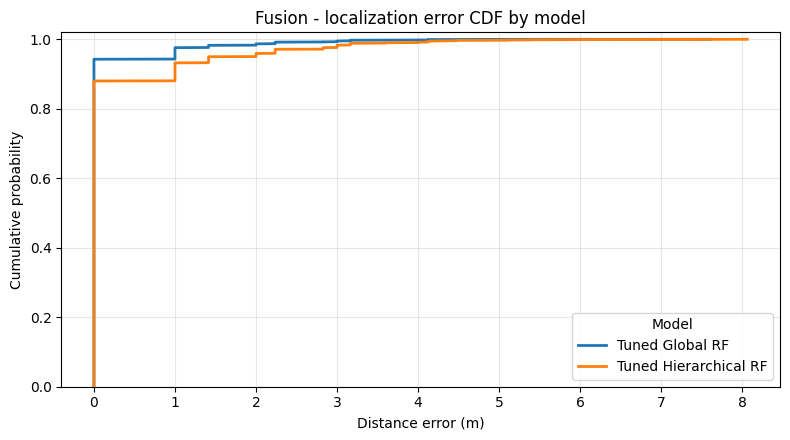

In [9]:
if SHOW_CDF_PLOTS and not tuned_summary.empty:
    from hierarchical_position_classifier import (
        _distance_errors,
        _random_forest_classifier,
        feature_columns,
        room_label_for_location,
        train_hierarchical_position_classifier,
    )

    tuning_plot_dir = tuning_dir / "plots"
    tuning_plot_dir.mkdir(parents=True, exist_ok=True)
    tuning_feature_dataframes = _ensure_tuning_feature_dataframes()
    train_df, test_df = split_dataframe(
        tuning_feature_dataframes["Fusion"],
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE,
        split_mode="block",
        n_blocks=BLOCK_COUNT,
    )
    fusion_tuned_predictions = []

    for classifier in TUNING_CLASSIFIERS:
        row = tuned_summary.loc[
            (tuned_summary["dataset"] == "Fusion")
            & (tuned_summary["classifier"] == classifier)
        ].iloc[0]
        params = _params_from_summary_row(row)
        if classifier == "Global":
            model = _random_forest_classifier(random_state=RANDOM_STATE, **params)
            columns = feature_columns(train_df)
            model.fit(train_df[columns], train_df["location"].astype(str))
            pred_locations = model.predict(test_df[columns])
            pred_rooms = np.array(
                [room_label_for_location(loc) for loc in pred_locations], dtype=object
            )
            model_label = "Tuned Global RF"
        else:
            model = train_hierarchical_position_classifier(
                train_df,
                random_state=RANDOM_STATE,
                esp_mode="local",
                room_local_esps=ROOM_LOCAL_ESPS,
                **params,
            )
            pred_rooms, pred_locations = model.predict(test_df)
            model_label = "Tuned Hierarchical RF"

        fusion_tuned_predictions.append(
            pd.DataFrame(
                {
                    "dataset": "Fusion",
                    "model": model_label,
                    "split": "block",
                    "true_room": test_df["label"].astype(int).to_numpy(),
                    "pred_room": pred_rooms,
                    "true_location": test_df["location"].astype(str).to_numpy(),
                    "pred_location": pred_locations,
                    "distance_error": _distance_errors(
                        test_df["location"],
                        pred_locations,
                        row_spacing=ROW_SPACING,
                        column_spacing=COLUMN_SPACING,
                    ),
                }
            )
        )

    plot_localization_error_cdf_by_model(
        pd.concat(fusion_tuned_predictions, ignore_index=True),
        dataset="Fusion",
        save_path=tuning_plot_dir / "cdf_tuned_fusion_block.png",
    )
    del train_df, test_df, fusion_tuned_predictions
    gc.collect()


In [10]:
write_manifest(
    results_dir=results_dir,
    preproc_opts=preproc_opts,
    feat_opts=feat_opts,
    classifier_params={
        "n_estimators": 300,
        "max_features": "sqrt",
        "random_state": RANDOM_STATE,
        "class_weight": "balanced",
        "block_count": BLOCK_COUNT,
    },
    splits=list(SPLIT_MODES),
    test_size=TEST_SIZE,
    feature_dataframes=feature_dataframes,
    tuned_hyperparameters=globals().get("tuned_hyperparameters"),
    tuned_hyperparameters_direct=globals().get("tuned_hyperparameters_direct"),
)


[results] Manifest written to c:\Users\pedro\OneDrive - Universidade de Coimbra\Ambiente de Trabalho\tese\thesis-project\results\preproc=agc-off\feat=win60-step30\manifest.json
